In [1]:
from src.main import get_data, get_returns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
data = get_data(["AAPL", "GOOG", "MSFT"], "2020-01-01", "2024-01-01")
mean_returns, cov_matrix = get_returns(data)

[*********************100%***********************]  3 of 3 completed


In [3]:
weights = np.random.random(len(mean_returns))
weights /= np.sum(weights)

weights

array([0.37195478, 0.2553031 , 0.37274212])

In [4]:
mc_sims = 100
T = 100
init_portfolio = 10_000
mean_m = np.full(shape=(T, len(weights)), fill_value=mean_returns)

mean_m = mean_m.T

portfolio_sims = np.zeros(shape=(T, mc_sims))

L = np.linalg.cholesky(cov_matrix)
for m in range(0, mc_sims):
    Z = np.random.normal(size=(T, len(weights)))
    print(Z)
    
    daily_returns = mean_m + np.inner(L, Z)
    portfolio_sims[:, m] = np.cumprod(np.inner(weights, daily_returns.T) + 1) * init_portfolio

[[ 3.10514015e-01 -3.63722301e-02  4.74370269e-01]
 [-3.77901189e-01  3.43448721e-01  1.54668900e+00]
 [-1.31955598e+00  1.12803743e-01  7.40477827e-01]
 [-4.94317076e-01 -1.15290327e+00  2.20328926e+00]
 [ 1.62807608e+00  3.65407900e-01 -2.45588785e-01]
 [ 8.74972234e-01 -2.23835706e-01 -1.86888490e+00]
 [-4.63596619e-01  7.67365802e-01  7.32643090e-01]
 [ 4.32266481e-02 -4.29660937e-01 -9.82933028e-01]
 [-6.31758211e-01  1.24524044e+00 -7.27849635e-01]
 [-1.02911529e+00  3.04093761e-01  8.60094092e-01]
 [ 6.60689299e-01 -2.29191156e-01  4.96199335e-01]
 [-8.88419433e-02  2.04795076e-01  8.38450695e-01]
 [-7.18935119e-01  5.75327047e-01 -1.19840408e+00]
 [ 9.67434172e-01  1.30107681e+00  3.79900195e-01]
 [ 7.96396305e-02  5.87015822e-01  1.22991812e+00]
 [-8.09557457e-01 -4.35002967e-01 -1.14231051e+00]
 [ 7.67764194e-01  4.17965757e-01 -1.14531038e+00]
 [-9.21300746e-01 -1.07140151e+00  1.41139764e+00]
 [ 6.10012525e-02 -3.90217403e-01 -3.22367712e+00]
 [-8.72512951e-01  1.25503180e+

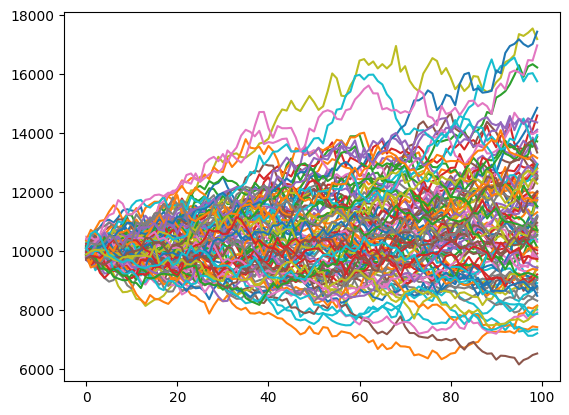

In [5]:
plt.plot(portfolio_sims)
plt.show()

In [6]:
def mc_var(returns, alpha=5):
    """In: pd.Series of returns
    Out: percentile of return distribution to a given confidence level alpha"""
    if isinstance(returns, pd.Series):
        return np.percentile(returns, alpha)
    else:
        raise TypeError("Expected a pd.Series")
    
def mc_conditional_var(returns, alpha=5):
    """In: pd.Series of returns
    Out: cvar or expected shortfall to a given confidence level alpha"""
    if isinstance(returns, pd.Series):
        below_var = returns <= mc_var(returns, alpha)
        return returns[below_var].mean()
    else:
        raise TypeError("Expected a pd.Series")

In [7]:
port_results = pd.Series(portfolio_sims[-1, :])

VaR = init_portfolio - mc_var(port_results, alpha=5)
CVaR = init_portfolio - mc_conditional_var(port_results, alpha=5)

print(f"VaR: {VaR:.2f}")
print(f"CVaR: {CVaR:.2f}")


VaR: 2085.01
CVaR: 2727.57
